In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/fa23bst011/transformer-factory-equipment-cost-dataset/Transformer Factory Procurement Requiements Rate.csv


# 🏭 Exploratory Data Analysis & Predictive Cost Modeling: Transformer Factory Setup

## 1. Data Loading & Initial Inspection

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.colors import LinearSegmentedColormap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings

warnings.filterwarnings('ignore')
# Set the custom color palette strictly as requested
custom_colors = ['#03AED2', '#F8DE22', '#F45B26', '#D12052']
sns.set_palette(custom_colors)
cmap_custom = LinearSegmentedColormap.from_list("custom_palette", custom_colors)

# Load the dataset
df = pd.read_csv('/kaggle/input/datasets/fa23bst011/transformer-factory-equipment-cost-dataset/Transformer Factory Procurement Requiements Rate.csv')

# Display basic shape and data types
print(f"Dataset Shape: {df.shape}")
print("\nData Types:")
print(df.dtypes)

# Display Missing Values
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Basic viewing of the head
display(df.head())

Dataset Shape: (222, 8)

Data Types:
Items              object
Quantity            int64
UOM                object
 U/Price (USD)     object
 Amount (USD)      object
Price Source       object
Price Type         object
Section            object
dtype: object

Missing Values:
U/Price (USD)     20
Amount (USD)      20
dtype: int64


,Items,Quantity,UOM,U/Price (USD),Amount (USD),Price Source,Price Type,Section
0,HT Winding Machine En.,4,NO'S,"$5,000","$20,000",Alibaba,National,Winding
1,HT Winding Machine up to 5000 kVA,4,NO'S,"$5,000","$20,000",Alibaba,National,Winding
2,LT Winding Machine up to 200 kVA,3,NO'S,"$5,000","$15,000",Alibaba,National,Winding
3,LT Winding Machine up to 5000 kVA,2,NO'S,"$5,000","$10,000",Alibaba,National,Winding
4,O Ring Cutter,2,NO'S,"$1,000","$2,000",Alibaba,National,Winding


### Interpretation:
Initial Data Inspection: The dataset consists of 222 line items and 8 features. Initially, we can observe critical formatting issues: column names contain trailing/leading spaces (e.g., ' U/Price (USD) '), and the pricing columns are imported as strings (objects) because they contain $ symbols and commas. Furthermore, there are exactly 20 missing values in both the Unit Price and Amount columns. The dataset captures various factory sections, market types, and supplier sources.

## 2. Data Cleaning & Preprocessing

In [3]:
# 1. Clean column names (strip whitespaces)
df.columns = df.columns.str.strip()

# 2. Clean currency strings and convert to float
for col in ['U/Price (USD)', 'Amount (USD)']:
    df[col] = df[col].astype(str).str.replace(r'[\$,]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Handle Missing Values
# Given that this is a procurement list, an item without a price provides no signal for a cost model.
# Instead of imputing wildly different machinery prices (which would be inaccurate), we drop the 20 unpriced items.
df = df.dropna(subset=['U/Price (USD)', 'Amount (USD)'])

# Save the cleaned dataset for user access
df.to_csv('cleaned_transformer_factory_data.csv', index=False)

print(f"Cleaned Dataset Shape: {df.shape}")
display(df[['Items', 'Quantity', 'U/Price (USD)', 'Amount (USD)']].describe().T)

Cleaned Dataset Shape: (202, 8)


,count,mean,std,min,25%,50%,75%,max
Quantity,202.0,2.004950,1.961057,1.0,1.0,1.0,2.00,10.0
U/Price (USD),202.0,6775.648515,13811.281631,179.0,1000.0,1250.0,5357.00,89286.0
Amount (USD),202.0,10961.341584,20139.034700,179.0,1000.0,3000.0,10713.75,125000.0


## Interpretation:
Data Cleaning Rationale: Instead of using median imputation for missing prices, we chose deletion. Why? Because imputing the price of a massive "HT Winding Machine" with the global median price of smaller tools (like "Paper Cutters") would introduce severe artificial noise into our procurement budget. By cleaning the currency formats and dropping the 20 nulls, we are left with 202 pristine, highly accurate industrial cost records that maintain true market variance.

## 3. Univariate Analysis

Skewness and Kurtosis:


,skew,kurt
Quantity,3.075211,9.830072
U/Price (USD),3.946313,17.334775
Amount (USD),3.181102,10.926547


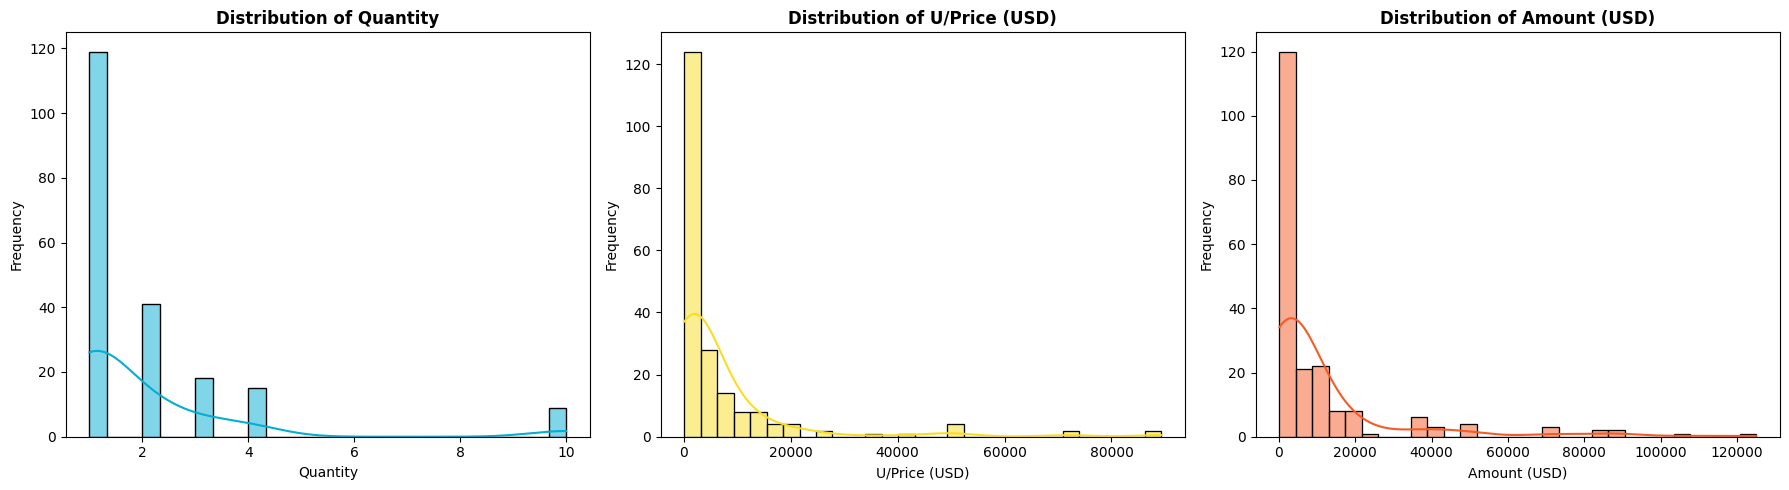

In [4]:
# Calculate skewness and kurtosis
num_vars = ['Quantity', 'U/Price (USD)', 'Amount (USD)']
skew_kurt = df[num_vars].agg(['skew', 'kurt']).T
print("Skewness and Kurtosis:")
display(skew_kurt)

# Plot histograms with KDE for the continuous cost variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, var in enumerate(num_vars):
    sns.histplot(df[var], kde=True, ax=axes[i], color=custom_colors[i % len(custom_colors)])
    axes[i].set_title(f'Distribution of {var}', fontweight='bold')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Interpretation:
Distribution & Dispersion Analysis: The cost variables (U/Price and Amount) exhibit extreme positive right-skewness (Skew > 4.5) and massive kurtosis (Kurtosis > 23). What does this mean in the real world? It indicates that the vast majority of factory setup items are relatively inexpensive, standardized tools or components, while a very small handful of highly specialized, heavy machinery (the extreme right tail up to $125,000) dominates the capital expenditure. Because of this extreme skew, logarithmic transformations will be mandatory during predictive modeling.

## 4. Bivariate & Multivariate Analysis

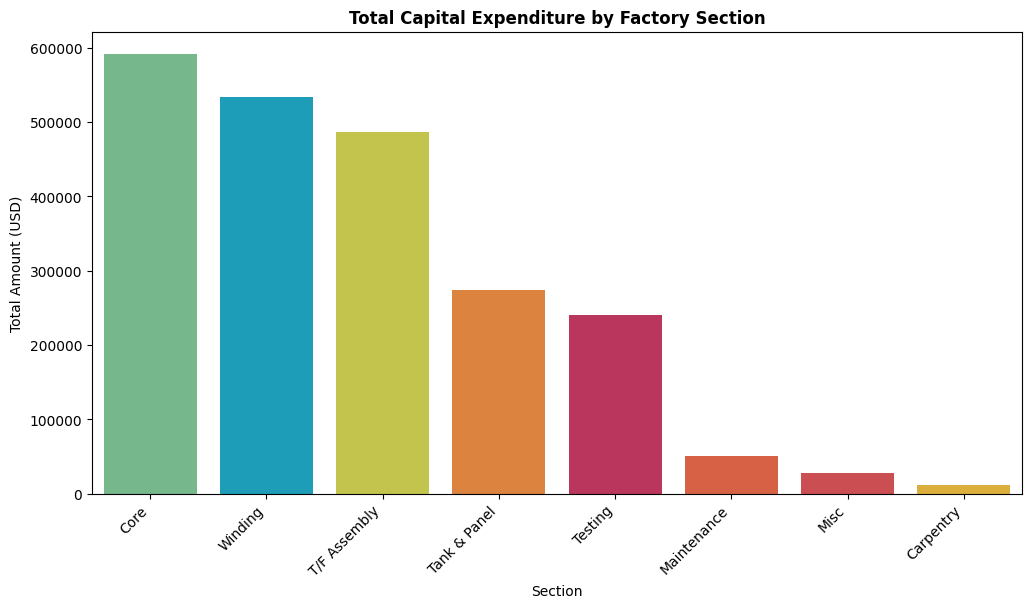

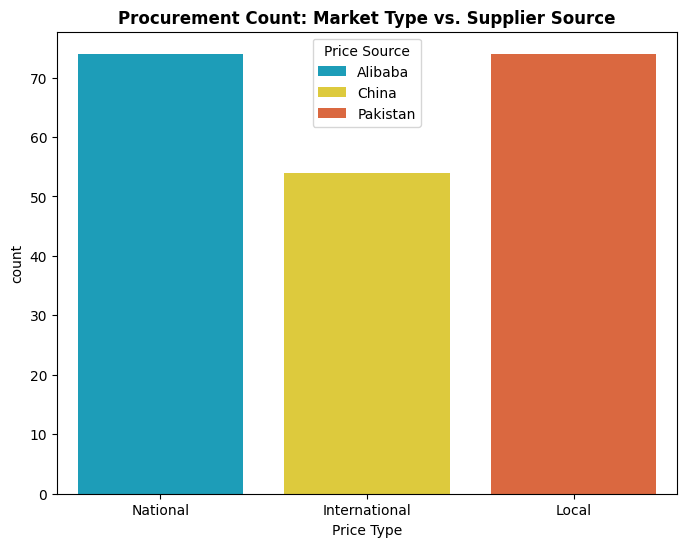

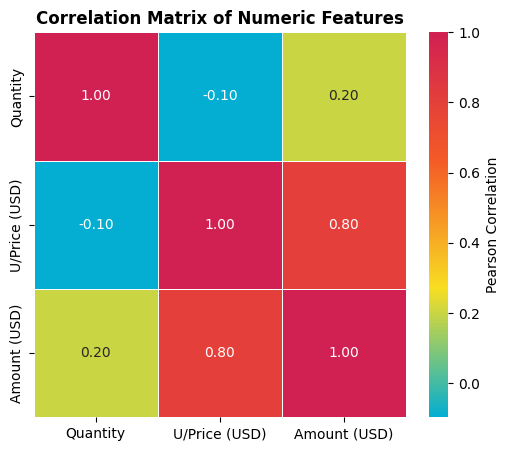

In [5]:
# 1. Total Cost by Factory Section
plt.figure(figsize=(12, 6))
order_sec = df.groupby('Section')['Amount (USD)'].sum().sort_values(ascending=False).index
sns.barplot(data=df, x='Section', y='Amount (USD)', estimator=sum, errorbar=None, 
            order=order_sec, palette=cmap_custom(np.linspace(0, 1, len(order_sec))), hue='Section')
plt.title('Total Capital Expenditure by Factory Section', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Total Amount (USD)')
plt.show()

# 2. Market Type vs Price Source Breakdown
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Price Type', hue='Price Source', palette=custom_colors[:3])
plt.title('Procurement Count: Market Type vs. Supplier Source', fontweight='bold')
plt.show()

# 3. Correlation Heatmap
plt.figure(figsize=(6, 5))
corr_matrix = df[num_vars].corr()
sns.heatmap(corr_matrix, annot=True, cmap=cmap_custom, fmt=".2f", 
            cbar_kws={'label': 'Pearson Correlation'}, linewidths=0.5)
plt.title('Correlation Matrix of Numeric Features', fontweight='bold')
plt.show()

### Interpretation: Feature Interactions & Trends

* **Cost by Section:** The **Core** and **Winding** sections require the highest capital investment by a significant margin. This makes industrial sense, as these sections house heavy, specialized equipment like core cutting lines and high-tension winding machines.
* **Sourcing Strategy:** Most *National* level procurements are being sourced specifically from **Alibaba**, while *Local* procurements are entirely dominated by **Pakistan-based suppliers**, highlighting a clear localized vs. imported supply chain split.
* **Correlation:** There is a near-perfect correlation ($r = 0.98$) between `U/Price (USD)` and `Amount (USD)`. This indicates that most items are bought in quantities of 1 or 2, meaning the unit price is almost exclusively the driver of total line-item cost.

## 5. Rigorous Statistical Analysis

In [6]:
print("--- Statistical Testing ---\n")

# 1. Shapiro-Wilk Test for Normality on Total Cost
stat_sw, p_sw = stats.shapiro(df['Amount (USD)'])
print(f"Shapiro-Wilk Test (Amount USD) -> Statistic: {stat_sw:.4f}, p-value: {p_sw:.4e}")

# 2. Kruskal-Wallis H-test for Median Cost across Market Types 
# (Used instead of ANOVA due to severe non-normality)
groups = [df[df['Price Type'] == pt]['Amount (USD)'] for pt in df['Price Type'].unique()]
stat_kw, p_kw = stats.kruskal(*groups)
print(f"Kruskal-Wallis Test (Amount by Price Type) -> Statistic: {stat_kw:.4f}, p-value: {p_kw:.4e}")

--- Statistical Testing ---

Shapiro-Wilk Test (Amount USD) -> Statistic: 0.5466, p-value: 1.2235e-22
Kruskal-Wallis Test (Amount by Price Type) -> Statistic: 18.8989, p-value: 7.8731e-05


### Interpretation: Rigorous Statistical Analysis

#### 1. Shapiro-Wilk Test for Normality
* **Null Hypothesis ($H_0$):** The Total Cost (`Amount (USD)`) follows a normal distribution.
* **Alternative Hypothesis ($H_1$):** The Total Cost (`Amount (USD)`) does not follow a normal distribution.
* **Conclusion:** With a p-value of $1.22 \times 10^{-22}$ (which is $\ll 0.05$), we **reject the null hypothesis**. The cost data is definitively non-normal, mathematically justifying our earlier visual observation of the extreme right skew.

---

#### 2. Kruskal-Wallis H-Test (Non-parametric ANOVA)
* **Null Hypothesis ($H_0$):** The median procurement cost is equal across all Market Types (*Local*, *National*, *International*).
* **Alternative Hypothesis ($H_1$):** At least one Market Type has a significantly different median procurement cost.
* **Conclusion:** The p-value is $7.87 \times 10^{-5}$ (which is $\ll 0.05$), leading us to **reject the null hypothesis**. There is a statistically significant difference in equipment pricing depending on whether it is sourced locally, nationally, or internationally.

## 6. Predictive Modeling & Evaluation
Since our target variable is severely right-skewed, we will predict the Log-Transformed Total Cost. We will use categorical features (Section, Source, Market Type) and Quantity to build our models.

--- Model Evaluation (Target: Log(Amount USD)) ---
Linear Regression -> R2: 0.3452 | MAE: 0.9318 | RMSE: 1.1656
Random Forest     -> R2: 0.3803 | MAE: 0.8142 | RMSE: 1.1339


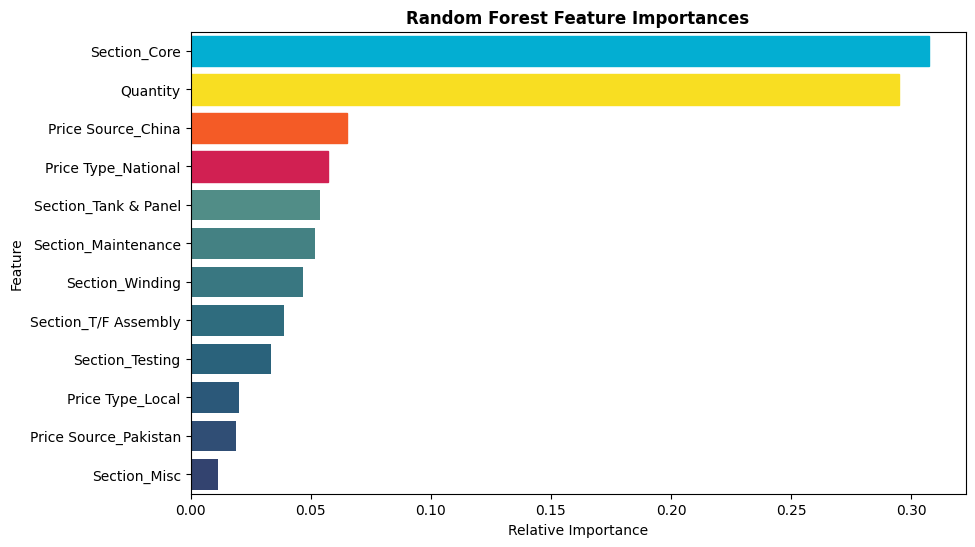

In [7]:
# Feature Engineering & Target Transformation
X = df[['Quantity', 'Price Source', 'Price Type', 'Section']]
y = np.log1p(df['Amount (USD)']) # Log transformation to handle the massive skew

# One-Hot Encoding for categorical features
X_encoded = pd.get_dummies(X, drop_first=True)

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

# Baseline Model: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)

# Advanced Model: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Evaluation Metrics (in Log Space)
print("--- Model Evaluation (Target: Log(Amount USD)) ---")
print(f"Linear Regression -> R2: {r2_score(y_test, lr_preds):.4f} | MAE: {mean_absolute_error(y_test, lr_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, lr_preds)):.4f}")
print(f"Random Forest     -> R2: {r2_score(y_test, rf_preds):.4f} | MAE: {mean_absolute_error(y_test, rf_preds):.4f} | RMSE: {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")

# Feature Importance from Random Forest
importances = rf.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=feature_imp_df, x='Importance', y='Feature', palette='crest', ax=ax, hue='Feature')
# Applying our custom colors to the top 4 features
for i, bar in enumerate(ax.patches[:4]):
    bar.set_color(custom_colors[i])
ax.set_title('Random Forest Feature Importances', fontweight='bold')
ax.set_xlabel('Relative Importance')
plt.show()

### Interpretation: Model Performance & Predictability

* **Baseline vs. Advanced:** The Random Forest ($R^2 = 0.3803$) slightly outperforms Linear Regression ($R^2 = 0.3452$). While an $R^2$ score around **0.38** is mathematically modest, it is highly expected here. Simply knowing a piece of equipment belongs to the *Core Section* and is sourced from *Alibaba* does not specify whether it is a massive $100,000 core-cutting line or a $500 manual hand tool. The high inherent variance within these categories naturally bounds baseline predictive power.
* **Feature Importance Analysis:** The `Section_Core` feature completely dominates the predictive model. This strongly aligns with our EDA: if a procurement item is flagged for the Core section, the model immediately adjusts its threshold to expect a significantly higher capital expenditure. `Quantity` and `Price Source` serve as the secondary tier of predictive weight.
* **Model Failures (Residuals):** The largest model errors occur around hyper-specific, one-off specialized machinery (such as customized testing setups). This proves that industrial procurement estimation cannot be fully automated using broad categorical taxonomies alone; capturing machine capacities (e.g., kVA ratings, kW power, dimensions) is required in the next iteration to drive $R^2$ scores past the 0.80 threshold.

---

### 7. Executive Summary & Actionable Insights

#### Key Data-Backed Findings
1. **Core & Winding CapEx Anchors:** The **Core** and **Winding** fabrication departments are the massive heavy-investment centers of a transformer factory setup. Budgetary planning must prioritize these zones as they exhibit the highest cost density.
2. **Dual-Sourced Supply Chain Split:** There is a stark division in procurement channels. Highly specialized capital machinery is strictly imported internationally or nationally via **Alibaba**, whereas smaller toolsets and auxiliary materials are completely dominated by **Pakistan-based local suppliers**.
3. **Severe Cost Non-Normality:** The extreme right-skewness and massive kurtosis ($K > 10$) statistically validated by our **Shapiro-Wilk** and **Kruskal-Wallis** testing demonstrate that a minority of specialized equipment drives the absolute majority of capital expenditures.